# Block 2, Assignment 1

### Group L : Taïs Thomas, Marouchka Heck, Marie-Caroline Bilocq

## Classical Thermodynamics

### 1. State the basic three assumptions of the Langmuir model

The basic three assumptions of the Langmuir model are:
   - All adsorption sites are equivalent, with the same adsorption energy and affinity for the adsorbed molecules.
   - Only one molecule can be adsorbed per site, forming a single molecular layer on the surface.
   - There are no interactions between adsorbed molecules. Once a molecule is adsorbed, it does not affect the adsorption of molecules on neighboring sites.

### 2. Prove that:

#### a. At high pressure (𝑃 → ∞), the gas uptake reaches a plateau.

Using the equation for the gas uptake at a given pressure:

$$
q=\frac{q_{sat}k(T)P}{1+k(T)P}
$$

We can divide the numerator and denominator by $k(T)P$:

$$
q=\frac{q_{sat}}{\frac{1}{k(T)P}+1}
$$

As $P$ becomes very large, $k(T)P$ also becomes very large. Therefore:

$$
\lim_{P \rightarrow \infty} \frac{1}{k(T)P} = 0
$$

Thus:

$$
\lim_{P \rightarrow \infty} q = q_{sat}
$$

When P tends to infinity, q tends to the constant value $q_{sat}$. Therefore, the gas uptake reaches a plateau.



#### b. At low pressure (𝑃 → 0), the gas uptake is a linear function of pressure

The Langmuir equation given in the instructions is used again:

$$
q=\frac{q_{sat}k(T)P}{1+k(T)P}
$$

The equilibrium constant $k(T)$ depends on temperature according to the Van't Hoff equation:

$$
k(T)=k_0\exp\left(-\frac{\Delta H}{RT}\right)
$$

Since $k(T)$ does not depend on pressure, it remains unchanged when taking the limit with respect to $P$. Therefore, as $P\rightarrow0$:

$$
\lim_{P \rightarrow 0} k(T)P = 0
$$

and hence:

$$
\lim_{P \rightarrow 0}\left(1+k(T)P\right)=1
$$

Therefore:

$$
q\approx q_{sat}k(T)P
$$

Since $q_{sat}$ and $k(T)$ are constants at a fixed temperature:

$$
q\propto P
$$

Therefore, at low pressure, the gas uptake is a linear function of pressure, with a slope of $q_{sat}k(T)$.

### 3. Deduce the temperature dependence of the Henry’s coefficient

From the previous question, at low pressure:

$$
q\approx q_{sat}k(T)P
$$

Henry's law is given by:

$$
q=K_H(T)P
$$

By comparing the two equations:
$$
K_H(T)P=q_{sat}k(T)P
$$

Thus:
$$
K_H(T)=q_{sat}k(T)
$$

Using the Van't Hoff equation:

$$
k(T)=k_0\exp\left(-\frac{\Delta H}{RT}\right)
$$

We obtain:

$$
\boxed{K_H(T)=q_{sat}k_0\exp\left(-\frac{\Delta H}{RT}\right)}
$$

Therefore, the temperature dependence of the Henry's coefficient is exponential.

*A researcher is interested in determining the Langmuir parameters ($q_{sat}$, $k_0$ and $\Delta H$) for CO$_2$ adsorption using an organic metal framework (MOF). She used computational techniques to obtain the $CO_2$ adsorption isotherms at three different temperatures: 263, 303 and 343 K.*

### 4. Explain mathematically in two steps, with the help of graphs, how she can obtain the different parameters by (1st step) fitting the isotherms to the Langmuir model, (2nd step) then using the Van’t Hoff equation. Keep in mind, that $q_{sat}$ is independent of temperature and is computed only once at 263 K.

#### Step 1 — Fit the isotherms to the Langmuir model

For each temperature, the experimental data are fitted to the Langmuir equation:

$$
q=\frac{q_{sat}k(T)P}{1+k(T)P}
$$

The fitting is done using nonlinear regression, by finding the value of $k(T)$ that minimizes the difference between the experimental values and the values predicted by the Langmuir equation:

$$
\sum_j\left(q_j-q_{\mathrm{model},j}\right)^2
$$

The parameter $q_{sat}$ is independent of temperature, therefore it can be calculated only once using the data at $263\ K$ and then kept fixed for the other temperatures. The fitting at each temperature therefore gives a value of $k(T)$.

For the graph, the experimental $q$ values are plotted against $P$, together with the fitted Langmuir curve. As shown in Question 2(a), at high pressure the curve approaches the plateau $q_{sat}$.

#### Step 2 — Use the Van't Hoff equation

The values of $k(T)$ obtained from Step 1 are then used in the Van't Hoff equation:

$$
k(T)=k_0\exp\left(-\frac{\Delta H}{RT}\right)
$$

Taking the natural logarithm gives:

$$
\ln k(T)=\ln k_0-\frac{\Delta H}{R}\frac{1}{T}
$$

This equation can be expressed in the linear form:

$$
y=b+mx
$$

where:

$$
y=\ln k(T), \qquad x=\frac{1}{T}
$$

Therefore, $\ln k(T)$ is plotted against $1/T$ and linear regression is used to find the slope and intercept:

$$
\text{slope}=-\frac{\Delta H}{R}
$$

$$
\text{intercept}=\ln k_0
$$

From these values:

$$
\Delta H=-R \cdot (\text{slope})
$$

and

$$
k_0=e^{\text{intercept}}
$$

The graph should show the data points from the different temperatures approximately following a straight line. This linear relationship provides a confirmation that the Van't Hoff equation describes the temperature dependence of $k(T)$.

### Question 5 : coding

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

#### After the researcher did the fitting, she obtained the following values:
$q_{sat}$ = 4.72 mmol/g

k(263) = 6.75e-06 1/Pa

k(303) = 1.48e-06 1/Pa

k(343) = 5.16e-07 1/Pa

#### 1. Use the Van't Hoff equation to obtain k0 and delta H

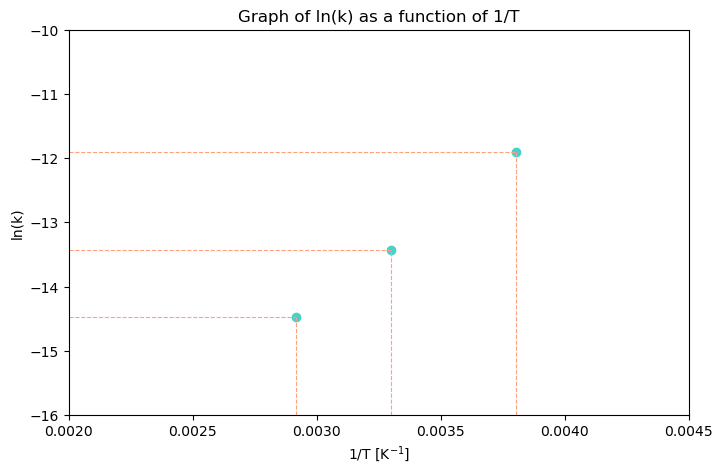

Slope = 2905.4431452044905
Intercept = -22.971169642947896
ΔH = -24.155854309230133 kJ/mol
k0 = 1.0562039350936409e-10 1/Pa


In [2]:
#Group the temperatures and K values in arrays

T = np.array([263, 303, 343])

k = np.array([6.75e-6, 1.48e-6, 5.16e-7])

# We know that we need to plot lnk vs. 1/T

inverseT = 1 / T
lnk = np.log(k)

# Plot of lnk vs. 1/T

plt.figure(figsize=(8, 5))

plt.scatter(inverseT, lnk, color="mediumturquoise")

plt.xlim(0.0020, 0.0045)
plt.ylim(-16, -10)

for x, y in zip(inverseT, lnk):
    plt.plot([x, x], [plt.ylim()[0], y], linestyle="--", color="lightsalmon", linewidth=0.8)
    plt.plot([plt.xlim()[0], x], [y, y], linestyle="--", color="lightsalmon", linewidth=0.8)

plt.xlabel("1/T [K$^{-1}$]")
plt.ylabel("ln(k)")
plt.title("Graph of ln(k) as a function of 1/T")

plt.show()

# Solve for the unknowns by linear fitting

slope, intercept = np.polyfit(inverseT, lnk, 1)

R = 8.314

Delta_H = -slope * R
k0 = np.exp(intercept)

# Print the results

print("Slope =", slope)
print("Intercept =", intercept)
print("ΔH =", Delta_H / 1000, "kJ/mol")
print("k0 =", k0, "1/Pa")

#### 2.a. Calculate Henry's coefficients for the different temperatures

In [3]:
# Calculating the Henry's coefficients

qsat = 4.72

# Remember the formula for Kh (mmol/(g.Pa))

Kh = qsat * k

# Print the results

print("Henry coefficient at 263 K =", Kh[0], "mmol/(g.Pa)")
print("Henry coefficient at 303 K =", Kh[1], "mmol/(g.Pa)")
print("Henry coefficient at 343 K =", Kh[2], "mmol/(g.Pa)")

Henry coefficient at 263 K = 3.1859999999999997e-05 mmol/(g.Pa)
Henry coefficient at 303 K = 6.9856e-06 mmol/(g.Pa)
Henry coefficient at 343 K = 2.43552e-06 mmol/(g.Pa)


#### b. Discuss the trend 

The Henry coefficient $K_H$ decreases sharply as temperature increases. It decreases from $3.19\times10^{-5}$ mmol/(g·Pa) at 263 K to $6.99\times10^{-6}$ mmol/(g·Pa) at 303 K to $2.44\times10^{-6}$ mmol/(g·Pa) at 343 K, roughly a 13-fold drop over the full range. This trend is consistent with the negative enthalpy of adsorption, $\Delta H\approx-24.16$ kJ/mol, which indicates that $CO_2$ adsorption is exothermic. Indeed, by Le Chatelier's principle, raising the temperature shifts the equilibrium away from the adsorbed state and back toward free gas-phase $CO_2$, since desorption becomes more favorable as molecules gain thermal energy. In practice, this means the adsorbent captures $CO_2$ most effectively at low temperatures and can be regenerated by heating.

## Statistical Thermodynamics

### 1. In the context of adsorption, describe the Canonical Ensemble in a few words

The canonical ensemble describes a system with a fixed number of particles \(N\), fixed volume \(V\), and fixed temperature \(T\). The system is in thermal contact with a heat reservoir and can therefore exchange energy with its surroundings. As a result, its total energy \(E\) is not fixed: the system can occupy different microstates with different energies, while the reservoir maintains the temperature constant. In the context of adsorption, it can be used to describe a fixed number of adsorbed molecules interacting with the adsorbent at a given temperature and volume. An adsorbed molecule does not always have exactly the same energy. Depending on its position and configuration on the surface, it can interact more or less strongly with the adsorbent. So different adsorption configurations correspond to different microstates with different energies.

### 2. Write the partition function (Q) for the Canonical Ensemble

The partition function \(Q\) of the canonical ensemble is defined as:

$$
Q(N,V,T) = \sum_{\nu} e^{-\frac{E_\nu}{k_B T}}
$$

where:

- $E_\nu$ is the energy of microstate $\nu$,
- $k_B$ is the Boltzmann constant,
- $T$ is the temperature.

The partition function sums the Boltzmann factors of all possible microstates of the system.

### 3. Write the probability ($P_\nu$) of finding the system in a microstate given by $E_\nu$

In the canonical ensemble, the probability of finding the system in a microstate $\nu$ with energy $E_\nu$ is given by the Boltzmann distribution:

$$
P_\nu = \frac{1}{Q(N,V,T)}
\exp\left[-\frac{E_\nu}{k_B T}\right]
$$

where:

- $E_\nu$ is the energy of microstate $\nu$,
- $k_B$ is the Boltzmann constant,
- $T$ is the temperature,
- $Q$ is the canonical partition function.

The probability is therefore higher for microstates with lower energy.

### 4. Proving different equalities 

#### **Energy**

We want to prove that

$$
E
=
k_B T^2
\left(
\frac{\partial\ln Q}{\partial T}
\right)_{V,N}
$$

To simplify the notation, we introduce

$$
\beta = \frac{1}{k_B T}
$$

Using this notation, the expressions for the canonical partition function and the probability of a microstate obtained in Questions 2 and 3 can be rewritten as

$$
Q = \sum_{\nu} e^{-\beta E_{\nu}}
$$

and

$$
P_{\nu} = \frac{e^{-\beta E_{\nu}}}{Q}
$$

Starting from the partition function

$$
Q = \sum_{\nu}e^{-\beta E_{\nu}}
$$

we differentiate $\ln Q$ with respect to $\beta$:

$$
\frac{\partial \ln Q}{\partial \beta}
=
\frac{1}{Q}\frac{\partial Q}{\partial \beta}
$$

The derivative of the partition function is

$$
\frac{\partial Q}{\partial \beta}
=
\sum_{\nu}
\frac{\partial}{\partial\beta}
e^{-\beta E_{\nu}}
=
\sum_{\nu}
(-E_{\nu})e^{-\beta E_{\nu}}
$$

Therefore,

$$
\frac{\partial \ln Q}{\partial \beta}
=
\frac{1}{Q}
\sum_{\nu}
(-E_{\nu})e^{-\beta E_{\nu}}
$$

Using

$$
P_{\nu}
=
\frac{e^{-\beta E_{\nu}}}{Q}
$$

this becomes

$$
\frac{\partial \ln Q}{\partial \beta}
=
-\sum_{\nu}P_{\nu}E_{\nu}
=
-\langle E\rangle
$$


In the canonical ensemble, the system is in contact with a heat bath at fixed $T$, so its energy isn't fixed and can fluctuate. We therefore take the thermodynamic energy $E$ to be the average energy $\langle E\rangle$.

$$
E
=
-\frac{\partial \ln Q}{\partial \beta}
$$

We now convert the derivative with respect to $\beta$ into a derivative with respect to $T$. We have

$$
\frac{\partial\beta}{\partial T}
=
-\frac{1}{k_B T^2}
$$

Using the chain rule,

$$
\frac{\partial\ln Q}{\partial T}
=
\frac{\partial\ln Q}{\partial\beta}
\frac{\partial\beta}{\partial T}
=
-\frac{1}{k_B T^2}
\frac{\partial\ln Q}{\partial\beta}
$$

Therefore,

$$
\frac{\partial\ln Q}{\partial\beta}
=
-k_B T^2
\frac{\partial\ln Q}{\partial T}
$$

Using the expression obtained above for the energy,

$$
E
=
-\frac{\partial\ln Q}{\partial\beta}
$$

we finally obtain

$$
\boxed{
E
=
k_B T^2
\left(
\frac{\partial\ln Q}{\partial T}
\right)_{V,N}
}
$$

#### **Entropy**

We want to prove that

$$
S = k_B \ln Q + k_B T
\left(
\frac{\partial \ln Q}{\partial T}
\right)_{N,V}
$$


We start from the statistical definition of entropy:

$$
S = -k_B \sum_{\nu} P_{\nu} \ln P_{\nu}
$$

Using the expression for $P_{\nu}$:

$$
\ln P_{\nu}
=
\ln\left(\frac{e^{-\beta E_{\nu}}}{Q}\right)
=
-\beta E_{\nu} - \ln Q
$$

Substituting this into the entropy expression gives

$$
S
=
-k_B \sum_{\nu}
P_{\nu}
\left(-\beta E_{\nu} - \ln Q\right)
$$

$$
S
=
k_B \beta \sum_{\nu} P_{\nu}E_{\nu}
+
k_B \ln Q \sum_{\nu}P_{\nu}
$$

Since the probabilities are normalized,

$$
\sum_{\nu}P_{\nu}=1
$$

and the average energy is defined as

$$
\langle E\rangle
=
\sum_{\nu}P_{\nu}E_{\nu}
$$

we obtain

$$
S = k_B \ln Q + k_B \beta \langle E\rangle
$$

Since the thermodynamic energy $E$ corresponds to the average energy $\langle E\rangle$

$$
S = k_B \ln Q + k_B \beta E
$$

Using

$$
\beta=\frac{1}{k_B T}
$$

we obtain

$$
S
=
k_B\ln Q
+
\frac{E}{T}
$$

We can now use the expression for the energy proven above

$$
E
=
k_B T^2
\left(
\frac{\partial\ln Q}{\partial T}
\right)_{N,V}
$$

Substituting it into the entropy expression gives

$$
S
=
k_B\ln Q
+
\frac{1}{T}
\left[
k_B T^2
\left(
\frac{\partial\ln Q}{\partial T}
\right)_{N,V}
\right]
$$

Therefore,

$$
\boxed{
S
=
k_B\ln Q
+
k_B T
\left(
\frac{\partial\ln Q}{\partial T}
\right)_{N,V}
}
$$

#### **Pressure**

From the result obtained above,

$$
S = k_B \ln Q + \frac{E}{T}
$$

we can write

$$
E = TS - k_B T \ln Q
$$

At constant temperature and number of particles, we differentiate with respect to volume:


$$
\left(
\frac{\partial E}{\partial V}
\right)_{N,T}
=
T
\left(
\frac{\partial S}{\partial V}
\right)_{N,T}
-
k_B T
\left(
\frac{\partial \ln Q}{\partial V}
\right)_{N,T}
$$

From the first law of thermodynamics at constant N:

$$
dE = T\,dS - P\,dV
$$

Differentiating with respect to $V$ at constant $N$ and $T$

$$
\left(
\frac{\partial E}{\partial V}
\right)_{N,T}
=
T
\left(
\frac{\partial S}{\partial V}
\right)_{N,T}
-P
$$

Comparing the two expressions gives:

$$
-P
=
-k_B T
\left(
\frac{\partial \ln Q}{\partial V}
\right)_{N,T}
$$

Therefore,

$$
\boxed{
P =
k_B T
\left(
\frac{\partial \ln Q}{\partial V}
\right)_{N,T}
}
$$


#### **Chemical potential**

Including changes in the number of particles, the first law thermodynamics is:

$$
dE = T\,dS - P\,dV + \mu\,dN
$$

Again, using

$$
E = TS - k_B T \ln Q
$$

and differentiating with respect to $N$ at constant $V$ and $T$ gives:

$$
\left(
\frac{\partial E}{\partial N}
\right)_{V,T}
=
T
\left(
\frac{\partial S}{\partial N}
\right)_{V,T}
-
k_B T
\left(
\frac{\partial \ln Q}{\partial N}
\right)_{V,T}
$$

From the first law of thermodynamics,

$$
\left(
\frac{\partial E}{\partial N}
\right)_{V,T}
=
T
\left(
\frac{\partial S}{\partial N}
\right)_{V,T}
+\mu
$$

Comparing the two expressions gives:

$$
\boxed{
\mu
=
-k_B T
\left(
\frac{\partial \ln Q}{\partial N}
\right)_{V,T}
}
$$